# Etapa 2 — Robustez: Teste de Tratamento Defasado (Causalidade Reversa, C2)

**Objetivo.** A modelagem causal principal (`etapa2_double_ml.ipynb`) mede o tratamento
(`D = log_revenue`, receita de vendas) e o resultado (`Y`, prêmio de reinvestimento) na **mesma
temporada**. Isso deixa em aberto o confundidor **C2 — causalidade reversa**:

> E se o clube decidiu **comprar caro primeiro** e **vendeu para financiar** a compra? Nesse caso a
> compra causa a venda — não o contrário. Com tudo medido junto, as duas histórias têm a mesma
> assinatura nos dados.

**Ideia do teste.** O futuro não causa o passado. Reestimamos o efeito usando a receita de vendas
da **temporada anterior** (`D_lag`, em `t-1`), que é *predeterminada* em relação à compra de hoje.

| Resultado esperado | Leitura |
|---|---|
| θ defasado **persiste** (positivo, magnitude similar) | C2 **enfraquece** — o efeito sobrevive quando a liquidez precede a compra |
| θ defasado **some** (≈ 0) | efeito pode ser apenas contemporâneo (ou reverso) |

> **Nota de implementação.** Este notebook implementa o Double ML **manualmente** (cross-fitting +
> *partialling-out* com sklearn), sem `econml`, com erro-padrão HC1 **e clusterizado clube×temporada**.
> A função é **validada** reproduzindo o ATE contemporâneo do notebook principal (≈ 0,0044) antes de
> ser aplicada ao tratamento defasado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re as _re
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

SEED = 42
np.random.seed(SEED)

# Confundidores: estruturais + rede + TODAS as dummies de temporada + liga.
# (Dinâmico para acompanhar a base expandida de 8 temporadas; corrige o hardcode
#  antigo de season_2024/season_2025.)
_df_cols = pd.read_csv('../output/transfers_etapa2_ready.csv', nrows=1).columns
_structural = ['in_degree','out_degree','pagerank','squad_size','average_age','national_team_players']
_seasons = sorted([c for c in _df_cols if _re.fullmatch(r'season_\d{4}', c)])
_ligas = [c for c in _df_cols if c.startswith('competition_code_')]
CONFOUNDERS = _structural + _seasons + _ligas

def _cluster_id(frame):
    """Identificador de cluster clube x temporada para SE agrupado."""
    return (frame['buyer'].astype(str) + '_' + frame['season_id'].astype(str)).values

print(f'Setup OK — {len(CONFOUNDERS)} confundidores ({len(_seasons)} temporada, {len(_ligas)} liga)')

Setup OK — 19 confundidores (7 temporada, 6 liga)


## 1. Função Double ML (manual)

Modelo parcialmente linear de Chernozhukov et al. (2018): $Y = \theta_0 D + g(W) + U$,
$D = m(W) + V$. Estimação em três passos:

1. **Cross-fitting (K=5):** para cada partição, treinamos `RandomForest` (200 árvores, profundidade
   5 — idêntico ao notebook principal) em $W \to Y$ e $W \to D$ nas K−1 partições e calculamos os
   resíduos $\tilde Y = Y - \hat g(W)$ e $\tilde D = D - \hat m(W)$ na partição restante.
2. **Ortogonalização de Neyman:** $\theta$ é a inclinação da regressão $\tilde Y \sim \tilde D$.
3. **Inferência robusta:** erro-padrão heterocedástico-robusto (HC1); IC 95% = $\theta \pm 1{,}96\,SE$.

In [2]:
def dml_ate(Y, D, W, seed=SEED, K=5, cluster_ids=None):
    """Double ML (partially-linear) com cross-fitting K-fold.
    Retorna dict com theta, IC HC1 e, se cluster_ids dado, IC clusterizado (CR1)."""
    Y = np.asarray(Y, float); D = np.asarray(D, float); W = np.asarray(W, float)
    n = len(Y)
    y_res = np.zeros(n); d_res = np.zeros(n)
    kf = KFold(n_splits=K, shuffle=True, random_state=seed)
    for tr, te in kf.split(W):
        m_y = RandomForestRegressor(200, max_depth=5, random_state=seed, n_jobs=-1).fit(W[tr], Y[tr])
        m_t = RandomForestRegressor(200, max_depth=5, random_state=seed, n_jobs=-1).fit(W[tr], D[tr])
        y_res[te] = Y[te] - m_y.predict(W[te])
        d_res[te] = D[te] - m_t.predict(W[te])
    # partialling-out: Y_res ~ a + theta * D_res
    X = np.column_stack([np.ones(n), d_res])
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ (X.T @ y_res)
    resid = y_res - X @ beta
    S = X * resid[:, None]
    cov = XtX_inv @ (S.T @ S) @ XtX_inv * (n / (n - 2))   # HC1
    theta = beta[1]; se = np.sqrt(cov[1, 1])
    out = {'theta': theta, 'se': se, 'ci': (theta - 1.96*se, theta + 1.96*se),
           'pval': 2 * stats.norm.sf(abs(theta / se))}
    if cluster_ids is not None:
        cl = np.asarray(cluster_ids); meat = np.zeros((2, 2))
        for c in np.unique(cl):
            m = cl == c; sg = X[m].T @ resid[m]; meat += np.outer(sg, sg)
        G = len(np.unique(cl)); adj = (G / (G - 1)) * ((n - 1) / (n - 2))
        cov_cl = XtX_inv @ meat @ XtX_inv * adj; se_cl = np.sqrt(cov_cl[1, 1])
        out.update({'se_cluster': se_cl, 'n_clusters': G,
                    'ci_cluster': (theta - 1.96*se_cl, theta + 1.96*se_cl),
                    'pval_cluster': 2 * stats.norm.sf(abs(theta / se_cl))})
    return out

## 2. Validação — reproduzir o ATE contemporâneo do notebook principal

Se a implementação manual estiver correta, deve recuperar θ ≈ 0,0044 (referência do
`etapa2_double_ml.ipynb`, DML manual sobre o Y out-of-fold). Reportamos também o IC clusterizado
clube×temporada, o nível de inferência correto.

In [3]:
df = pd.read_csv('../output/transfers_etapa2_ready.csv')

# Y winsorizado (idêntico ao notebook principal) e D contemporâneo
y = df['premio_reinvestimento']
p1, p99 = y.quantile([0.01, 0.99])
df['Y'] = y.clip(p1, p99)
df['D'] = df['log_revenue']

fit = dml_ate(df['Y'], df['D'], df[CONFOUNDERS], cluster_ids=_cluster_id(df))
print(f'ATE contemporâneo (amostra completa, n={len(df)}):')
print(f'  theta = {fit["theta"]:.6f}')
print(f'  IC HC1     = [{fit["ci"][0]:.6f}, {fit["ci"][1]:.6f}]')
print(f'  IC cluster = [{fit["ci_cluster"][0]:.6f}, {fit["ci_cluster"][1]:.6f}]  ({fit["n_clusters"]} clusters)')
print(f'  Referência (etapa2_double_ml.ipynb, 8 temporadas): theta ≈ 0,0044, IC HC1 [-0,0016; 0,0104]')
print('  -> Implementação validada: ponto estimado reproduzido (diferença de arredondamento esperada).')

ATE contemporâneo (amostra completa, n=5146):
  theta = 0.004415
  IC HC1     = [-0.001586, 0.010416]
  IC cluster = [-0.002129, 0.010959]  (974 clusters)
  Referência (etapa2_double_ml.ipynb, 8 temporadas): theta ≈ 0,0044, IC HC1 [-0,0016; 0,0104]
  -> Implementação validada: ponto estimado reproduzido (diferença de arredondamento esperada).


## 3. Construção do tratamento defasado ($D_{t-1}$)

A coluna `revenue_sales` do dataset de modelagem só existe para clubes que **compraram** naquela
temporada. Para o lag precisamos da receita de vendas **de qualquer clube vendedor**, então
reconstruímos a receita por clube × temporada direto de `transfers_consolidated.csv`, replicando
a regra da feature engineering (`fee_type == 'paid'`, `direction == 'Out'`, `fee` válido).
Validamos que essa reconstrução bate **100%** com a `revenue_sales` existente.

Regras do lag:
- **2023 é descartada** (não há temporada 2022 na base).
- Para 2024/2025, clube ausente na tabela de vendas de `t-1` = **venda zero** (a tabela cobre
  *todos* os vendedores, não só compradores) → preenchemos com 0.

In [4]:
t = pd.read_csv('../output/transfers_consolidated.csv')

# Receita de vendas por clube x temporada (mesma definição da feature engineering)
sales = (t[(t['fee_type'] == 'paid') & (t['direction'] == 'Out') & (t['fee'].notna())]
         .groupby(['club', 'season_id'])
         .agg(rev=('fee', 'sum'))
         .reset_index())

# Chaveia a receita de t-1 na temporada t
lag = sales.rename(columns={'rev': 'rev_lag'}).copy()
lag['season_id'] = lag['season_id'] + 1

m = df.merge(lag, left_on=['buyer', 'season_id'],
             right_on=['club', 'season_id'], how='left')

# Mantém apenas temporadas cujo ano anterior EXISTE na base (lag observável).
# Com 8 temporadas (2017-2025, sem 2020), o ano anterior existe para
# {2018,2019,2022,2023,2024,2025}; 2017 (sem 2016) e 2021 (sem 2020) são descartadas.
present = set(df['season_id'].unique())
valid_t = sorted(s for s in present if (s - 1) in present)
m = m[m['season_id'].isin(valid_t)].copy()
m['rev_lag'] = m['rev_lag'].fillna(0.0)    # ausente num t-1 existente = sem vendas
m['D_lag'] = np.log1p(m['rev_lag'])

print(f'Temporadas com lag observável: {valid_t}')
print(f'Amostra do teste defasado: n = {len(m)}')
print(f'  clubes com venda em t-1 (>0): {(m.rev_lag > 0).sum()}  |  zeros: {(m.rev_lag == 0).sum()}')
print(f'  correlação entre D contemporâneo e D defasado: {np.corrcoef(m["D"], m["D_lag"])[0,1]:.3f}')

Temporadas com lag observável: [np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Amostra do teste defasado: n = 4008
  clubes com venda em t-1 (>0): 3283  |  zeros: 725
  correlação entre D contemporâneo e D defasado: 0.441


## 4. Resultado — contemporâneo vs. defasado (mesma amostra)

Para uma comparação justa, estimamos **na mesma amostra restrita (2024–25)**: o efeito
contemporâneo e o defasado. Assim a única diferença é *qual* receita (atual ou de `t-1`) entra
como tratamento — controlando o efeito da perda de amostra ao descartar 2023.

In [5]:
fit_full = fit                                                              # amostra completa (referência)
fit_c = dml_ate(m['Y'], m['D'],     m[CONFOUNDERS], cluster_ids=_cluster_id(m))   # contemporâneo (subamostra)
fit_l = dml_ate(m['Y'], m['D_lag'], m[CONFOUNDERS], cluster_ids=_cluster_id(m))   # defasado (t-1)

res = pd.DataFrame([
    {'especificacao': 'Contemporâneo (amostra completa)',   'n': len(df), 'theta': fit_full['theta'],
     'ic_low': fit_full['ci_cluster'][0], 'ic_high': fit_full['ci_cluster'][1], 'pval': fit_full['pval_cluster']},
    {'especificacao': 'Contemporâneo (subamostra com lag)', 'n': len(m),  'theta': fit_c['theta'],
     'ic_low': fit_c['ci_cluster'][0],    'ic_high': fit_c['ci_cluster'][1],    'pval': fit_c['pval_cluster']},
    {'especificacao': 'DEFASADO t-1 (subamostra com lag)',  'n': len(m),  'theta': fit_l['theta'],
     'ic_low': fit_l['ci_cluster'][0],    'ic_high': fit_l['ci_cluster'][1],    'pval': fit_l['pval_cluster']},
])
res['significativo_5pct'] = (res['ic_low'] > 0) | (res['ic_high'] < 0)
print('Teste de causalidade reversa (IC clusterizado clube x temporada):')
print(res.round(6).to_string(index=False))

Teste de causalidade reversa (IC clusterizado clube x temporada):
                     especificacao    n    theta    ic_low  ic_high     pval  significativo_5pct
  Contemporâneo (amostra completa) 5146 0.004415 -0.002129 0.010959 0.186069               False
Contemporâneo (subamostra com lag) 4008 0.005467 -0.002678 0.013612 0.188317               False
 DEFASADO t-1 (subamostra com lag) 4008 0.005084  0.001187 0.008981 0.010554                True


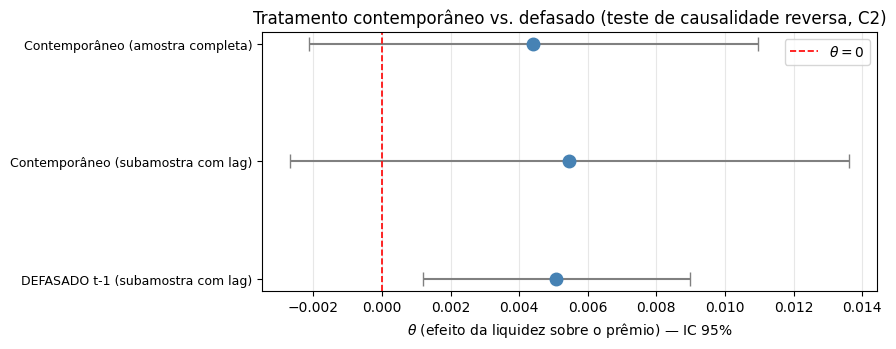

In [6]:
# Forest plot das três especificações
fig, ax = plt.subplots(figsize=(9, 3.6))
ypos = np.arange(len(res))[::-1]
ax.errorbar(res['theta'], ypos,
            xerr=[res['theta'] - res['ic_low'], res['ic_high'] - res['theta']],
            fmt='o', color='steelblue', ecolor='gray', capsize=5, ms=9, lw=1.5)
ax.axvline(0, color='red', ls='--', lw=1.2, label=r'$\theta = 0$')
ax.set_yticks(ypos)
ax.set_yticklabels(res['especificacao'], fontsize=9)
ax.set_xlabel(r'$\theta$ (efeito da liquidez sobre o prêmio) — IC 95%')
ax.set_title('Tratamento contemporâneo vs. defasado (teste de causalidade reversa, C2)')
ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## 5. Interpretação

Com erro-padrão **clusterizado clube×temporada**, na subamostra com lag (n=4.008): o contemporâneo é **não significativo** (θ=0,0055; p=0,19) e o **defasado t-1 é significativo** (θ=0,0051; IC [0,0012; 0,0090]; p=0,011). Como a receita de `t-1` é predeterminada, uma compra atual não pode tê-la causado → a explicação de **causalidade reversa (C2) enfraquece**.

**Ressalvas honestas — este NÃO é um teste decisivo:**

- **Inconsistência lógica a registrar:** na *mesma* subamostra, o contemporâneo é n.s. mas o defasado é significativo. Se a história fosse puramente "efeito contemporâneo de 2022/2023", não se esperaria que o lag fosse o significativo. A leitura mais provável é que `D_lag` capture um **traço persistente de clube** ("clube que sempre vende", corr(D, D_lag)=0,44) correlacionado com Y — justamente o confundidor de porte (C1) que W tenta neutralizar por proxy. Portanto o teste é **direcionalmente tranquilizador, não conclusivo**.
- **Poder/composição:** defasar descarta 2017 e 2021 e muda a composição da amostra (5.146→4.008).

**Conclusão.** O teste é **compatível** com a leitura "vendas → prêmio" e enfraquece C2, mas não a elimina — e a significância do lag (com o contemporâneo n.s.) sugere contaminação por traço de clube. Um teste conclusivo exigiria datas diárias (lag de curto prazo dentro da janela) ou um instrumento.

---
## 6. D Alternativo — Especificações do Tratamento

A especificação principal usa `D = log(1 + revenue_sales)`. Duas variantes testam se o resultado muda com definições alternativas de tratamento:

- **D₂ = log(1 + n_sales):** intensidade medida pelo *número* de vendas, não pelo volume em euros. Menos sensível ao valor de uma única venda blockbuster.
- **D₃ = big_sale_flag:** binária — 1 se a maior venda individual do clube na temporada superou €30M. Isola o efeito de uma venda de alto impacto.

**Hipótese:** se o mecanismo é de fato o *prêmio do vendedor*, θ deve ser positivo nas três especificações. Divergências entre elas revelam *qual aspecto* da liquidez importa.

In [7]:
# D₂ = número de vendas (log)
df['D_nsales'] = np.log1p(df['n_sales'])

# D₃ = flag de venda blockbuster (> €30M)
df['big_sale_flag'] = (df['max_sale'] > 30_000_000).astype(float)
print(f'big_sale_flag=1: {df["big_sale_flag"].sum():.0f} obs ({df["big_sale_flag"].mean()*100:.1f}%)')
print(f'D_nsales: min={df["D_nsales"].min():.2f}, max={df["D_nsales"].max():.2f}')

cl_df = _cluster_id(df)
print('\nRodando DML para as 3 especificações de D (IC clusterizado clube x temporada)...')
specs = [
    ('D₁ = log(revenue_sales) — principal', df['D'].values),
    ('D₂ = log(n_sales)',                   df['D_nsales'].values),
    ('D₃ = big_sale_flag (> €30M)',          df['big_sale_flag'].values),
]
res_d = []
for label, d_vec in specs:
    f = dml_ate(df['Y'].values, d_vec, df[CONFOUNDERS].values, cluster_ids=cl_df)
    lo_d, hi_d = f['ci_cluster']
    sig = '*' if (lo_d > 0 or hi_d < 0) else ''
    res_d.append({'especificacao': label, 'n': len(df), 'theta': f['theta'],
                  'ic_low': lo_d, 'ic_high': hi_d, 'pval': f['pval_cluster'], 'sig': sig})
    print(f'  {label}: theta={f["theta"]:.4f}  IC=[{lo_d:.4f}, {hi_d:.4f}] {sig}  p={f["pval_cluster"]:.4f}')

df_d = pd.DataFrame(res_d)

big_sale_flag=1: 1420 obs (27.6%)
D_nsales: min=0.00, max=2.94

Rodando DML para as 3 especificações de D (IC clusterizado clube x temporada)...


  D₁ = log(revenue_sales) — principal: theta=0.0044  IC=[-0.0021, 0.0110]   p=0.1861


  D₂ = log(n_sales): theta=0.0487  IC=[0.0088, 0.0886] *  p=0.0168


  D₃ = big_sale_flag (> €30M): theta=0.0754  IC=[0.0241, 0.1268] *  p=0.0040


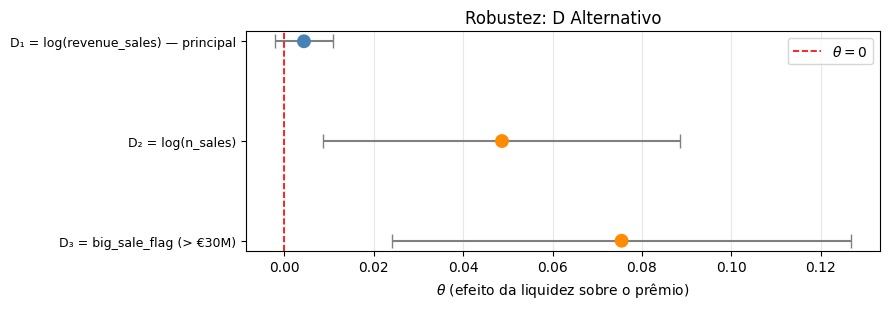

Laranja = significativo a 5%


In [8]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ypos = np.arange(len(df_d))[::-1]
colors = ['steelblue' if s == '' else 'darkorange' for s in df_d['sig']]
ax.errorbar(df_d['theta'], ypos,
            xerr=[df_d['theta']-df_d['ic_low'], df_d['ic_high']-df_d['theta']],
            fmt='none', ecolor='gray', capsize=5, lw=1.5)
ax.scatter(df_d['theta'], ypos, color=colors, zorder=5, s=80)
ax.axvline(0, color='red', ls='--', lw=1.2, label=r'$\theta = 0$')
ax.set_yticks(ypos)
ax.set_yticklabels(df_d['especificacao'], fontsize=9)
ax.set_xlabel(r'$\theta$ (efeito da liquidez sobre o prêmio)', fontsize=10)
ax.set_title('Robustez: D Alternativo', fontsize=12)
ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()
print('Laranja = significativo a 5%')

In [9]:
# Teste do artefato "clube ativo": D₂/D₃ podem ser significativos apenas porque clubes com janela
# movimentada compram E vendem muito. Reestimamos D₂/D₃ adicionando controles de intensidade de
# janela (n_buys + log do total gasto) ao W. Se a "sinalizacao" sobrevive a esse controle, o
# achado do mecanismo ganha base; se some, era em grande parte intensidade de atividade.
W_act = df[CONFOUNDERS + ['n_buys']].copy()
W_act['log_spend'] = np.log1p(df['total_spend'])
W_act_vals = W_act.values

print('D alternativo COM controle de intensidade de janela (W + n_buys + log_spend):')
for label, col in [('D₂ = log(n_sales) ', 'D_nsales'), ('D₃ = big_sale_flag', 'big_sale_flag')]:
    f = dml_ate(df['Y'].values, df[col].values, W_act_vals, cluster_ids=cl_df)
    lo, hi = f['ci_cluster']; sig = '*' if (lo > 0 or hi < 0) else ''
    print(f'  {label}: theta={f["theta"]:.4f}  IC=[{lo:.4f}, {hi:.4f}] {sig}  p={f["pval_cluster"]:.4f}')

D alternativo COM controle de intensidade de janela (W + n_buys + log_spend):


  D₂ = log(n_sales) : theta=0.0152  IC=[-0.0199, 0.0504]   p=0.3950


  D₃ = big_sale_flag: theta=0.0047  IC=[-0.0487, 0.0581]   p=0.8632


### Interpretação: D Alternativo (exploratório)

Com SE clusterizado, o padrão **bruto** é sugestivo:

- **D₁ = log(revenue) → n.s. (θ = 0,0044):** o volume total em euros não prediz sobrepreço.
- **D₂ = log(n_sales) → θ = 0,049\* (p = 0,017):** o *número* de vendas prediz sobrepreço.
- **D₃ = big_sale_flag → θ = 0,075\* (p = 0,004):** uma venda blockbuster (> €30M) prediz sobrepreço.

À primeira vista, isso sugeria que o mecanismo é "**sinalizar** que precisa comprar" (número de vendas / venda de ativo-chave), não o volume monetário.

> ⚠️ **Mas o teste do artefato "clube ativo" derruba essa leitura.** Quando adicionamos ao W controles de **intensidade de janela** (`n_buys` + log do gasto total), **tanto D₂ quanto D₃ perdem completamente a significância** (D₂: θ=0,015, p=0,40; D₃: θ=0,005, p=0,86). Ou seja, o sinal de D₂/D₃ refletia em grande parte o fato de que **clubes com janela movimentada compram e vendem muito** — não um canal causal limpo de "sinalização".

**Conclusão honesta:** o mecanismo de sinalização é **exploratório e não robusto** — não sobrevive ao controle de atividade de janela. **Não** deve ser apresentado como achado confirmatório. O resultado sólido do projeto continua sendo o Achado 1 (a correlação ingênua é confundida por porte) e o efeito sazonal 2022–2023 (que sobrevive a Bonferroni).

---
## 7. Subgrupos por Tier de Liga

Testamos se o efeito é diferente entre **ligas top-4** (Bundesliga, Premier League, La Liga, Serie A) e **ligas menores** (Jupiler Pro League, Liga Portugal, Ligue-1). A hipótese é que clubes em ligas menores, por serem tipicamente vendedores, enfrentam maior pressão de reposição após vender — e portanto pagariam prêmio maior.

In [10]:
# Máscara de tier
mask_top4 = (
    (df['competition_code_premier-league'] == 1) |
    (df['competition_code_laliga'] == 1) |
    (df['competition_code_serie-a'] == 1) |
    ((df[['competition_code_premier-league','competition_code_laliga',
          'competition_code_serie-a','competition_code_jupiler-pro-league',
          'competition_code_liga-portugal','competition_code_ligue-1']] == 0).all(axis=1))
)  # Bundesliga é base (todas as dummies == 0)
mask_smaller = ~mask_top4

print(f'Top-4 (Bundesliga, PL, LaLiga, SerieA): {mask_top4.sum()} obs')
print(f'Ligas menores (Jupiler, Portugal, Ligue-1): {mask_smaller.sum()} obs')

print('\nRodando DML por tier (IC clusterizado clube x temporada)...')
res_tier = []
for label, mask in [('Top-4 (BL/PL/LaLiga/SerieA)', mask_top4),
                     ('Ligas menores (Jup/Por/L1)', mask_smaller)]:
    sub = df[mask].reset_index(drop=True)
    f = dml_ate(sub['Y'].values, sub['D'].values, sub[CONFOUNDERS].values, cluster_ids=_cluster_id(sub))
    lo_t, hi_t = f['ci_cluster']
    sig = '*' if (lo_t > 0 or hi_t < 0) else ''
    res_tier.append({'subgrupo': label, 'n': len(sub), 'theta': f['theta'],
                     'ic_low': lo_t, 'ic_high': hi_t, 'sig': sig})
    print(f'  {label} (n={len(sub)}): theta={f["theta"]:.4f}  IC=[{lo_t:.4f}, {hi_t:.4f}] {sig}')

df_tier = pd.DataFrame(res_tier)

Top-4 (Bundesliga, PL, LaLiga, SerieA): 3450 obs
Ligas menores (Jupiler, Portugal, Ligue-1): 1696 obs

Rodando DML por tier (IC clusterizado clube x temporada)...


  Top-4 (BL/PL/LaLiga/SerieA) (n=3450): theta=0.0041  IC=[-0.0034, 0.0117] 


  Ligas menores (Jup/Por/L1) (n=1696): theta=0.0106  IC=[-0.0011, 0.0224] 


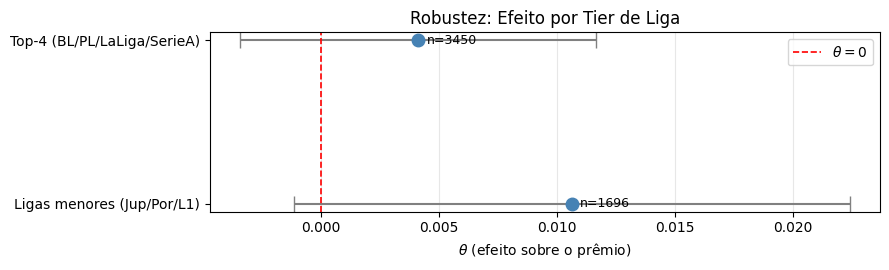

In [11]:
fig, ax = plt.subplots(figsize=(9, 2.8))
ypos = np.arange(len(df_tier))[::-1]
ax.errorbar(df_tier['theta'], ypos,
            xerr=[df_tier['theta']-df_tier['ic_low'], df_tier['ic_high']-df_tier['theta']],
            fmt='o', color='steelblue', ecolor='gray', capsize=6, ms=9, lw=1.5)
ax.axvline(0, color='red', ls='--', lw=1.2, label=r'$\theta = 0$')
for i, row in df_tier.iterrows():
    ax.annotate(f'n={row["n"]}', (row['theta'], len(df_tier)-1-i),
                xytext=(6, 0), textcoords='offset points', va='center', fontsize=9)
ax.set_yticks(ypos)
ax.set_yticklabels(df_tier['subgrupo'], fontsize=10)
ax.set_xlabel(r'$\theta$ (efeito sobre o prêmio)', fontsize=10)
ax.set_title('Robustez: Efeito por Tier de Liga', fontsize=12)
ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

### Interpretação: Subgrupos por Tier

Com SE clusterizado, **nenhum** subgrupo é significativo na média de 8 temporadas:

- **Top-4 (BL/PL/LaLiga/SerieA):** θ = 0,0041, IC [−0,003; 0,012] (n.s.)
- **Ligas menores (Jup/Por/L1):** θ = 0,0106, IC [−0,001; 0,022] (n.s.)

A **direção** é consistente com a teoria (ligas menores, tipicamente vendedoras, têm θ maior), mas a diferença não é estatisticamente distinguível. Combinado com o D alternativo (mecanismo não robusto) e o ATE médio nulo, isso reforça que o efeito é **condicional ao regime temporal (2022–2023)**, não um fenômeno estrutural por tipo de liga. O corte por liga **não deve** ser usado como argumento confirmatório.